<a href="https://colab.research.google.com/github/vivi0424/HSE-Computational-linguistics/blob/main/deborina_convnet_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


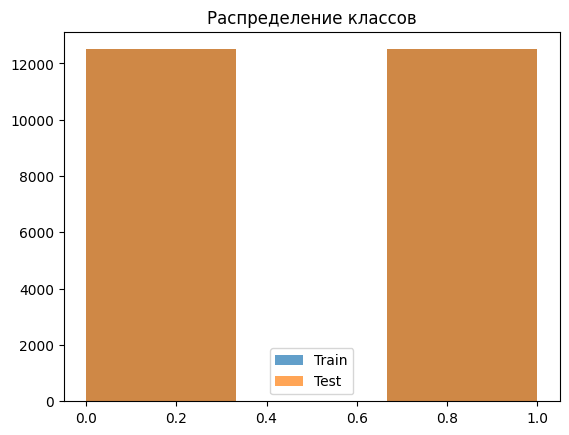

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
### ВАШ КОД ЗДЕСЬ ###
# Используйте tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)
(train_ds, test_ds), info = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

# Преобразуйте данные в numpy массивы (x_train, y_train), (x_test, y_test)
train_np = list(tfds.as_numpy(train_ds))
test_np  = list(tfds.as_numpy(test_ds))

x_train = np.array(
    [(x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else x) for x, y in train_np],
    dtype=object
)
y_train = np.array([int(y) for x, y in train_np], dtype=np.int32)

x_test = np.array(
    [(x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else x) for x, y in test_np],
    dtype=object
)
y_test = np.array([int(y) for x, y in test_np], dtype=np.int32)

print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.legend()
plt.title('Распределение классов')
plt.show()

## БЛОК 2: Предобработка текста

In [3]:
# 3. Создайте текстовый векторзатор (TextVectorization)
# Ограничьте словарь 10_000 самых частых слов, максимальную длину последовательности — 200 слов
vectorizer = keras.layers.TextVectorization(
    max_tokens=10_000,
    output_mode='int',
    output_sequence_length=200
)
# 4. Адаптируйте векторзатор на тренировочных текстах
vectorizer.adapt(x_train)
# 5. Примените векторзацию к данным
x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")

Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [4]:
# 6. Постройте модель CNN для текста СТРОГО ПО СПЕЦИФИКАЦИИ:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)
### ВАШ КОД ЗДЕСЬ ###
model = keras.Sequential([
    keras.layers.Input(shape=(200,)),
    keras.layers.Embedding(input_dim=10_000, output_dim=128),
    keras.layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 74ms/step - accuracy: 0.6910 - loss: 0.5545 - precision: 0.6814 - recall: 0.7008 - val_accuracy: 0.8576 - val_loss: 0.3318 - val_precision: 0.8693 - val_recall: 0.8459
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.9296 - loss: 0.1950 - precision: 0.9281 - recall: 0.9309 - val_accuracy: 0.8630 - val_loss: 0.3281 - val_precision: 0.8528 - val_recall: 0.8815
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.9917 - loss: 0.0451 - precision: 0.9916 - recall: 0.9919 - val_accuracy: 0.8620 - val_loss: 0.4133 - val_precision: 0.8423 - val_recall: 0.8949
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.9992 - loss: 0.0075 - precision: 0.9990 - recall: 0.9995 - val_accuracy: 0.8622 - val_loss: 0.4679 - val_precision: 0.8857 - val_recall: 0.8356
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.9999 - loss: 0.0013 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 0.8672 - val_los

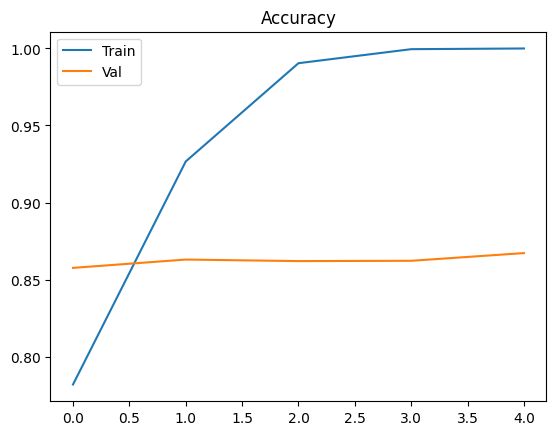

In [5]:
# 7. Скомпилируйте модель с оптимизатором 'adam', функцией потерь 'binary_crossentropy',
#    метриками ['accuracy', 'Precision', 'Recall']
### ВАШ КОД ЗДЕСЬ ###
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# 8. Обучите модель на 5 эпох с validation_split=0.2, batch_size=32
### ВАШ КОД ЗДЕСЬ ###
history = model.fit(
    x_train_vec, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 9. Постройте график точности (accuracy) на обучении и валидации
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

## БЛОК 5: Оценка

In [11]:
# 10. Оцените модель на тестовых данных
### ВАШ КОД ЗДЕСЬ ###
test_loss, test_acc, test_prec, test_rec = model.evaluate(
    x_test_vec, y_test,
    batch_size=32,
    verbose=0
)

print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")

# 11. Сделайте предсказания на первых 10 тестовых отзывах
#     и выведите: текст отзыва, истинный класс, предсказанный класс, вероятность
pred_probs = model.predict(x_test_vec[:10], verbose=0)

for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"

    pred_prob = pred_probs[i:i+1]  # (1, 1)
    pred_label = "POS" if pred_prob[0][0] > 0.5 else "NEG"

    print(f"{text[:200]}... | True: {true_label} | Pred: {pred_label} ({pred_prob[0][0]:.2f})")


Тестовая accuracy: 0.8640
Тестовая precision: 0.8625
Тестовая recall: 0.8660
There are films that make careers. For George Romero, it was NIGHT OF THE LIVING DEAD; for Kevin Smith, CLERKS; for Robert Rodriguez, EL MARIACHI. Add to that list Onur Tukel's absolutely amazing DING... | True: POS | Pred: POS (0.61)
A blackly comic tale of a down-trodden priest, Nazarin showcases the economy that Luis Bunuel was able to achieve in being able to tell a deeply humanist fable with a minimum of fuss. As an output fro... | True: POS | Pred: POS (0.52)
Scary Movie 1-4, Epic Movie, Date Movie, Meet the Spartans, Not another Teen Movie and Another Gay Movie. Making "Superhero Movie" the eleventh in a series that single handily ruined the parody genre.... | True: NEG | Pred: NEG (0.00)
Poor Shirley MacLaine tries hard to lend some gravitas to this mawkish, gag-inducing "feel-good" movie, but she's trampled by the run-away sentimentality of a film that's not the least bit grounded in... | True: NEG | 

## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1.  Итоговая accuracy на тесте: 0.8640.
2.  Разница между обучением и валидацией показывает обобщение. Здесь train больше val: train дошёл до примерно 1.0, а val до 0.86, т. е. есть переобучение.
3.  последний отзыв (“Every great once in a while…”) — True: POS, Pred: NEG (0.01). Вероятно, модель сконцентрировалась на негативных фразах и упоминании низкого рейтинга и из-за этого неправильно оценила общий посыл.